<a href="https://colab.research.google.com/github/KattaLasya/HPCLab/blob/main/HPC_LAB05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gcc --version

gcc (Ubuntu 11.4.0-1ubuntu1~22.04.2) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [ ]:
!apt-get update
!apt-get install -y build-essential

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,733 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,896 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:14 http://

In [ ]:
code = r'''
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

long long fib(int n) {
    long long x, y;

    if (n < 2)
        return n;

    #pragma omp task shared(x)
    x = fib(n - 1);

    #pragma omp task shared(y)
    y = fib(n - 2);

    #pragma omp taskwait
    return x + y;
}

int main(int argc, char* argv[]) {
    if (argc < 2) {
        printf("Usage: %s <n>\n", argv[0]);
        return 1;
    }

    int n = atoi(argv[1]);
    long long result;
    double start, end;

    start = omp_get_wtime();

    #pragma omp parallel
    {
        #pragma omp single
        result = fib(n);
    }

    end = omp_get_wtime();

    printf("Fib(%d) = %lld\n", n, result);
    printf("Time: %f seconds\n", end - start);

    return 0;
}
'''

with open("fib_task.c", "w") as f:
    f.write(code)

print("C program written to fib_task.c")

C program written to fib_task.c


In [ ]:
!gcc -fopenmp fib_task.c -o fib_task

In [ ]:
import subprocess
import re

inputs = [10, 15, 20, 25, 30]
times = []

for n in inputs:
    print(f"\nRunning for n = {n}")
    result = subprocess.check_output(["./fib_task", str(n)]).decode()
    print(result)

    match = re.search(r"Time:\s*([0-9.]+)", result)
    if match:
        times.append(float(match.group(1)))
    else:
        times.append(None)

print("Execution Times:", times)


Running for n = 10
Fib(10) = 55
Time: 0.004106 seconds


Running for n = 15
Fib(15) = 610
Time: 0.002302 seconds


Running for n = 20
Fib(20) = 6765
Time: 0.029102 seconds


Running for n = 25
Fib(25) = 75025
Time: 0.197598 seconds


Running for n = 30
Fib(30) = 832040
Time: 0.889062 seconds

Execution Times: [0.004106, 0.002302, 0.029102, 0.197598, 0.889062]


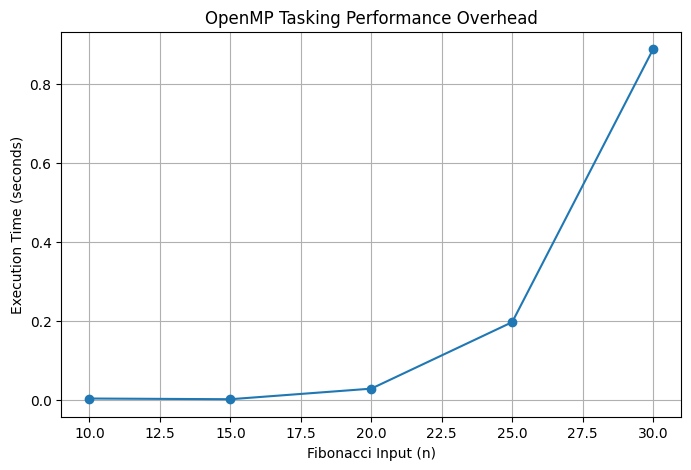

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(inputs, times, marker='o')
plt.xlabel("Fibonacci Input (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("OpenMP Tasking Performance Overhead")
plt.grid(True)
plt.show()